In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


In [2]:
# Read just the first 500 rows
df = pd.read_csv('pollution.csv', nrows=500)

#  a mini-version for GitHub
df.to_csv('pollution_sample.csv', index=False)
print("Data shape:", df.shape)
df.head()


Data shape: (500, 29)


,Unnamed: 0,State Code,County Code,Site Num,Address,State,County,City,Date Local,NO2 Units,...,SO2 Units,SO2 Mean,SO2 1st Max Value,SO2 1st Max Hour,SO2 AQI,CO Units,CO Mean,CO 1st Max Value,CO 1st Max Hour,CO AQI
0,0,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,3.000000,9.0,21,13.0,Parts per million,1.145833,4.2,21,NaN
1,1,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,3.000000,9.0,21,13.0,Parts per million,0.878947,2.2,23,25.0
2,2,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,2.975000,6.6,23,NaN,Parts per million,1.145833,4.2,21,NaN
3,3,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,2.975000,6.6,23,NaN,Parts per million,0.878947,2.2,23,25.0
4,4,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-02,Parts per billion,...,Parts per billion,1.958333,3.0,22,4.0,Parts per million,0.850000,1.6,23,NaN


In [3]:
# 3. Select features for clustering
features = ['NO2 Mean', 'O3 Mean', 'SO2 Mean', 'CO Mean']
X = df[features]


In [4]:
# 4. Handle missing values
X = X.dropna()

In [5]:
# 5. Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# 6. Train the K-Means model
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [7]:
# 7. Add clusters to dataframe
df_clean = df.loc[X.index].copy()
df_clean['Cluster'] = clusters

In [8]:
# 8. Show cluster summary
print("Cluster Summary (mean pollution levels):")
print(df_clean.groupby('Cluster')[features].mean())

Cluster Summary (mean pollution levels):
          NO2 Mean   O3 Mean  SO2 Mean   CO Mean
Cluster                                         
0        54.316234  0.009126  9.672513  2.455475
1        17.785188  0.029449  1.025613  0.712297
2        39.104658  0.013423  5.554526  1.703654
3        34.537171  0.020606  1.532954  1.039538


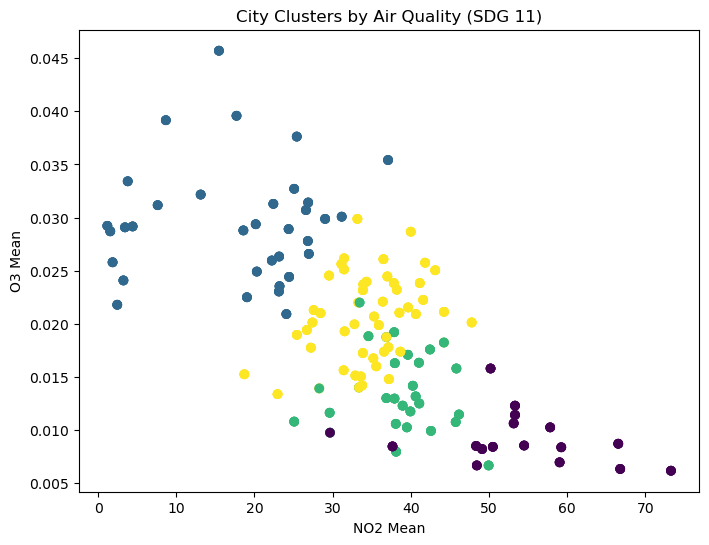

In [9]:
# 9. Visualize (choose two pollutants for 2D view)
plt.figure(figsize=(8,6))
plt.scatter(df_clean['NO2 Mean'], df_clean['O3 Mean'],
            c=df_clean['Cluster'], cmap='viridis')
plt.xlabel('NO2 Mean')
plt.ylabel('O3 Mean')
plt.title('City Clusters by Air Quality (SDG 11)')
plt.show()

In [11]:
# 10. Evaluate cluster quality
score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score:.3f}")

# Interpretation
if score >= 0.5:
    print("Good separation between clusters — air quality groups are distinct.")
elif score >= 0.3:
    print("Moderate separation — clusters are fairly distinct but may overlap.")
else:
    print("Weak clustering — air quality differences are not well separated.")


Silhouette Score: 0.324
Moderate separation — clusters are fairly distinct but may overlap.


In [12]:
print("\nSample clustered cities:")
print(df_clean[['City', 'State', 'Cluster']].head(10))


Sample clustered cities:
      City    State  Cluster
0  Phoenix  Arizona        1
1  Phoenix  Arizona        1
2  Phoenix  Arizona        1
3  Phoenix  Arizona        1
4  Phoenix  Arizona        3
5  Phoenix  Arizona        3
6  Phoenix  Arizona        3
7  Phoenix  Arizona        3
8  Phoenix  Arizona        2
9  Phoenix  Arizona        2


Ethical & Social Reflection:
The data may not represent all U.S. regions equally — smaller cities or areas with less monitoring might be underrepresented, which can bias cluster results.
However, this model supports sustainability by identifying areas needing more pollution control. Fairness can be improved by combining local and satellite data to avoid regional bias.